# EfficientSAM Segmentation (merve/EfficientSAM)

This notebook runs interactive-style segmentation with the Hugging Face model `merve/EfficientSAM` using point or box prompts.

- Point prompt labels: `1` (foreground), `0` (background)
- Box prompt labels: `[2, 3]` for top-left and bottom-right corners


In [ ]:
%pip -q install torch torchvision transformers pillow matplotlib requests setuptools gradio

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
from torchvision.transforms import ToTensor
from huggingface_hub import hf_hub_download

device = torch.device('cuda')
device


device(type='cuda')

In [2]:
REPO_ID = 'merve/EfficientSAM'
checkpoint_file = 'efficient_sam_s_gpu.jit' if torch.cuda.is_available() else 'efficient_sam_s_cpu.jit'
checkpoint_path = hf_hub_download(repo_id=REPO_ID, filename=checkpoint_file)

model = torch.jit.load(checkpoint_path, map_location=device)
model.eval();

print(f'Loaded: {checkpoint_file}')
print(f'Path: {checkpoint_path}')

Loaded: efficient_sam_s_gpu.jit
Path: /root/.cache/huggingface/hub/models--merve--EfficientSAM/snapshots/38bb0b55425abf62274ba4a8c51249e3d7298b70/efficient_sam_s_gpu.jit


In [3]:
def _resize_longest_side(image: Image.Image, target_size: int = 1024):
    w, h = image.size
    scale = target_size / max(w, h)
    new_w, new_h = int(w * scale), int(h * scale)
    return image.resize((new_w, new_h)), scale


@torch.no_grad()
def segment_with_points(image: Image.Image, points, point_labels, input_size: int = 1024):
    """
    points: list of [x, y] in original image coordinates
    point_labels: list of ints (1 foreground, 0 background)
    """
    resized_image, scale = _resize_longest_side(image, target_size=input_size)

    scaled_points = np.array([[int(x * scale), int(y * scale)] for x, y in points], dtype=np.float32)
    labels = np.array(point_labels, dtype=np.int64)

    img_tensor = ToTensor()(np.array(resized_image)).unsqueeze(0).to(device)
    pts_sampled = torch.tensor(scaled_points, dtype=torch.float32, device=device).view(1, 1, -1, 2)
    pts_labels = torch.tensor(labels, dtype=torch.int64, device=device).view(1, 1, -1)

    predicted_logits, predicted_iou = model(img_tensor, pts_sampled, pts_labels)

    masks = (torch.sigmoid(predicted_logits[0, 0]) > 0.5).cpu().numpy()
    ious = predicted_iou[0, 0].detach().cpu().numpy()
    best_idx = int(np.argmax(ious))

    return {
        'resized_image': resized_image,
        'mask': masks[best_idx],
        'all_masks': masks,
        'ious': ious,
        'best_idx': best_idx,
        'scaled_points': scaled_points,
        'scale': scale,
    }


def segment_with_box(image: Image.Image, box_xyxy, input_size: int = 1024):
    x0, y0, x1, y1 = box_xyxy
    points = [[x0, y0], [x1, y1]]
    box_labels = [2, 3]
    return segment_with_points(image, points, box_labels, input_size=input_size)


def show_overlay(image: Image.Image, mask, points=None, box=None, title='Segmentation Result'):
    img_np = np.array(image)

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(img_np)

    overlay = np.zeros((mask.shape[0], mask.shape[1], 4), dtype=np.float32)
    overlay[..., 0] = 1.0
    overlay[..., 3] = mask.astype(np.float32) * 0.45
    ax.imshow(overlay)

    if points is not None:
        points = np.array(points)
        ax.scatter(points[:, 0], points[:, 1], c='lime', s=60, marker='o')

    if box is not None:
        x0, y0, x1, y1 = box
        rect = plt.Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor='yellow', linewidth=2)
        ax.add_patch(rect)

    ax.set_title(title)
    ax.axis('off')
    plt.show()

Image size: (4032, 3024)


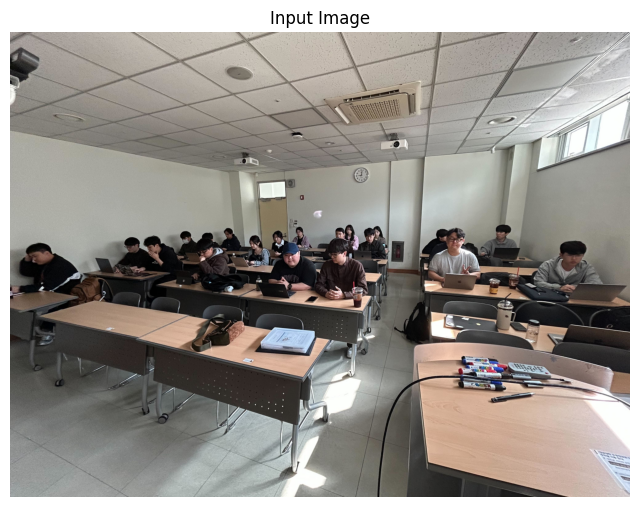

In [4]:
# Load example image (you can replace this with your own path).
# Example for local image:
# image = Image.open('/path/to/your_image.jpg').convert('RGB')

# image_url = 'https://huggingface.co/spaces/yunyangx/EfficientSAM/resolve/main/examples/image1.jpg'
# image = Image.open(__import__('urllib.request').request.urlopen(image_url)).convert('RGB')

img_path = 'img/xai506_example_image.jpg'
image = Image.open(img_path).convert('RGB')

print('Image size:', image.size)
plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.title('Input Image')
plt.axis('off')
plt.show()

## Interactive Prompting (Gradio UI - Stable for Remote Notebooks)

- Click image to add prompts
- `point` mode: choose foreground/background then click multiple points
- `box` mode: click 2 corners (top-left, bottom-right)
- `Run Segmentation` to execute EfficientSAM


In [5]:
# Install gradio once if needed:
# %pip -q install gradio

import gradio as gr
from PIL import ImageDraw


def _draw_prompt_preview(image: Image.Image, points, point_labels, box_points):
    canvas = image.copy().convert('RGB')
    draw = ImageDraw.Draw(canvas)

    for (x, y), label in zip(points, point_labels):
        r = 6
        color = 'lime' if int(label) == 1 else 'red'
        draw.ellipse((x - r, y - r, x + r, y + r), outline=color, width=3)

    if len(box_points) == 1:
        x0, y0 = box_points[0]
        r = 6
        draw.ellipse((x0 - r, y0 - r, x0 + r, y0 + r), outline='yellow', width=3)
    elif len(box_points) >= 2:
        (x0, y0), (x1, y1) = box_points[:2]
        x_min, x_max = sorted([x0, x1])
        y_min, y_max = sorted([y0, y1])
        draw.rectangle((x_min, y_min, x_max, y_max), outline='yellow', width=3)

    return canvas


def _overlay_mask(image: Image.Image, mask, alpha=0.45):
    base = np.array(image.convert('RGB'), dtype=np.float32)
    m = np.asarray(mask).astype(bool)

    color = np.array([255, 0, 0], dtype=np.float32)
    out = base.copy()
    out[m] = (1.0 - alpha) * out[m] + alpha * color

    return Image.fromarray(np.clip(out, 0, 255).astype(np.uint8))


def _on_select(image, mode, point_kind, points, point_labels, box_points, evt: gr.SelectData):
    if image is None or evt is None or evt.index is None:
        preview = image
        return preview, points, point_labels, box_points, 'Select an image first.'

    x, y = int(evt.index[0]), int(evt.index[1])
    points = points or []
    point_labels = point_labels or []
    box_points = box_points or []

    if mode == 'point':
        label = 1 if point_kind == 'foreground' else 0
        points = points + [[x, y]]
        point_labels = point_labels + [label]
        status = f'Added point ({x}, {y}), label={label}. Total points: {len(points)}'
    else:
        if len(box_points) >= 2:
            box_points = []
        box_points = box_points + [[x, y]]
        status = f'Added box corner ({x}, {y}). Corners: {len(box_points)}/2'

    preview = _draw_prompt_preview(image, points, point_labels, box_points)
    return preview, points, point_labels, box_points, status


def _on_clear(image):
    preview = image
    return preview, [], [], [], 'Cleared prompts.'


def _on_run(image, mode, points, point_labels, box_points, input_size):
    if image is None:
        return None, 'Select an image first.'

    points = points or []
    point_labels = point_labels or []
    box_points = box_points or []

    if mode == 'point':
        if len(points) == 0:
            return None, 'No point prompts. Add at least 1 point.'
        result = segment_with_points(image, points, point_labels, input_size=int(input_size))
        vis = _overlay_mask(result['resized_image'], result['mask'])
        vis = _draw_prompt_preview(vis, result['scaled_points'].astype(int).tolist(), point_labels, [])
        msg = f"Done. best_idx={result['best_idx']}, ious={np.round(result['ious'], 4).tolist()}"
        return vis, msg

    if len(box_points) < 2:
        return None, 'No valid box prompt. Click 2 corners.'

    (x0, y0), (x1, y1) = box_points[:2]
    x_min, x_max = sorted([x0, x1])
    y_min, y_max = sorted([y0, y1])
    box = [x_min, y_min, x_max, y_max]

    result = segment_with_box(image, box, input_size=int(input_size))
    vis = _overlay_mask(result['resized_image'], result['mask'])
    scaled_box = [int(v * result['scale']) for v in box]
    vis = _draw_prompt_preview(vis, [], [], [[scaled_box[0], scaled_box[1]], [scaled_box[2], scaled_box[3]]])
    msg = f"Done. best_idx={result['best_idx']}, ious={np.round(result['ious'], 4).tolist()}"
    return vis, msg


with gr.Blocks() as efficientsam_demo:
    gr.Markdown('### EfficientSAM Interactive Segmentation')

    with gr.Row():
        input_image = gr.Image(type='pil', label='Input Image', value=image)
        prompt_preview = gr.Image(type='pil', label='Prompt Preview', interactive=False)
        output_image = gr.Image(type='pil', label='Segmentation Output', interactive=False)

    with gr.Row():
        mode = gr.Radio(['point', 'box'], value='point', label='Prompt Mode')
        point_kind = gr.Radio(['foreground', 'background'], value='foreground', label='Point Label')
        input_size = gr.Slider(512, 1536, value=1024, step=64, label='Inference Resize (long side)')

    with gr.Row():
        clear_btn = gr.Button('Clear Prompts')
        run_btn = gr.Button('Run Segmentation')

    status = gr.Textbox(label='Status', value='Ready')

    points_state = gr.State([])
    labels_state = gr.State([])
    box_state = gr.State([])

    input_image.select(
        _on_select,
        inputs=[input_image, mode, point_kind, points_state, labels_state, box_state],
        outputs=[prompt_preview, points_state, labels_state, box_state, status],
    )

    clear_btn.click(
        _on_clear,
        inputs=[input_image],
        outputs=[prompt_preview, points_state, labels_state, box_state, status],
    )

    run_btn.click(
        _on_run,
        inputs=[input_image, mode, points_state, labels_state, box_state, input_size],
        outputs=[output_image, status],
    )


In [7]:
# Launch Gradio UI in notebook (or local URL in remote server)
efficientsam_demo.launch(share=True, inbrowser=False)


Rerunning server... use `close()` to stop if you need to change `launch()` parameters.
----
* Running on public URL: https://c91061dd152437dbcf.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
